In [4]:
using Revise
includet("../../scripts/single_influx.jl")

In [5]:
using ProgressMeter
using ColorSchemes
using UnPack

In [6]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Example PDE final state
*Might be good to change this to use the same PDE solution as shown in the coarsening bit*

In [9]:
f = jldopen("../../cluster_env/runs/single_influx_pdes4/data1_better.jld2")

@show countmap(f["ode_retcodes"])
@show countmap(f["sp_retcodes"]);

fmetadata = f["metadata"]
Klips = fmetadata.Klips_to_run

N = fmetadata.N
M = fmetadata.M
sN = fmetadata.sN
dx = fmetadata.L / sN

fparams = f["params"]
fode_fss = f["ode_final_states"]
fsp_fss = f["sp_final_states"]

Klips

countmap(f["ode_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 62, SciMLBase.ReturnCode.MaxIters => 1, SciMLBase.ReturnCode.Unstable => 1)
countmap(f["sp_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 46, SciMLBase.ReturnCode.Unstable => 11, SciMLBase.ReturnCode.MaxTime => 7)


8-element Vector{Tuple{Float64, Float64, Float64}}:
 (5.0, 1.0, 0.1)
 (11.0, 1.0, 0.1)
 (25.0, 1.0, 0.1)
 (5.0, 0.99, 0.1)
 (11.0, 0.99, 0.1)
 (25.0, 0.99, 0.1)
 (3.0, 0.7, 0.1)
 (3.0, 0.5, 0.1)

rcs = (SciMLBase.ReturnCode.Success, SciMLBase.ReturnCode.Success)


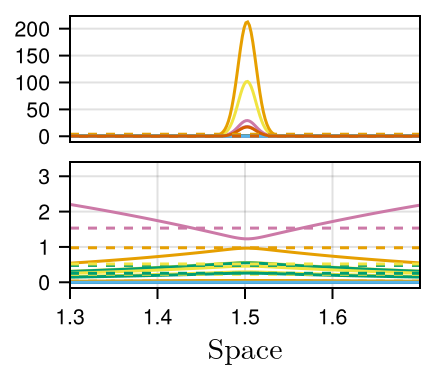

In [43]:
iK = 2
ir = 2
ps = fparams[ir,iK]
ode_fs = fode_fss[ir,iK]
pde_fs = fsp_fss[ir,iK];

rcs = f["ode_retcodes"][ir,iK], f["sp_retcodes"][ir,iK]
@show rcs

fig = Figure(;
    size=(double_col_width * 0.32, (double_col_width / golden_ratio) * 0.45),
    figure_padding=(8., 8., 8., 8.),
)

plot_spatial_fs!(fig[1,1], pde_fs, N, sN, dx, ode_fs)
sax, rax = fig.content

for ax in (sax, rax)
    ax.xlabelsize=10fontsize_ltex_pt
    ax.ylabelsize=10fontsize_ltex_pt
    ax.xticklabelsize=8fontsize_pt
    ax.yticklabelsize=8fontsize_pt
end
rax.xlabel = L"\text{Space}"
# rax.ylabel = L"\text{Resource concentrations}"
# sax.ylabel = L"\text{Strain biomass concentration}"

rowgap!(fig.layout.content[1].content, 10)

xlims!(rax, 1.3, 1.7)

Makie.save("../../figures2/fig4/sample_peak_si.pdf", fig)

fig

## The scatter plot

In [44]:
pde_means = mean(pde_fs; dims=2)[:];
_, maxsi = findmax(sum(pde_fs[1:N,:]; dims=1)[:]);

In [71]:
xx = theme_latexfonts()

Attributes with 1 entry:
  fonts => Attributes()

In [75]:
xx.fonts.regular[]

FTFont (family = NewComputerModern Math, style = Regular)

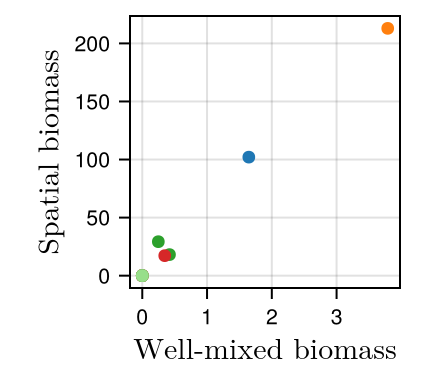

In [88]:
fig = Figure(;
    size=(double_col_width * 0.32, (double_col_width / golden_ratio) * 0.45),
    figure_padding=(8., 8., 8., 8.),
)

ax = Axis(fig[1,1];
    # aspect=DataAspect(),
    aspect=AxisAspect(1.),
    xlabel="Well-mixed biomass",
    ylabel="Spatial biomass",
    xlabelfont=xx.fonts.regular[],
    ylabelfont=xx.fonts.regular[],
    xlabelsize=10fontsize_ltex_pt,
    ylabelsize=10fontsize_ltex_pt,
    xticklabelsize=8fontsize_pt,
    yticklabelsize=8fontsize_pt,
)

# cs = [Makie.wong_colors()[mod(i, 7)+1] for i in 1:20]
cs = [ColorSchemes.tab20[mod(i, 7)+1] for i in 1:20]

# scatter!(ax, ode_fs[1:N], pde_means[1:N]; color=cs)
scatter!(ax, ode_fs[1:N], pde_fs[1:N,maxsi]; color=cs)

# scatter!(ax, ode_fs[1:N] ./ sum(ode_fs[1:N]), pde_means[1:N] ./ sum(pde_means[1:N]); color=cs)

# scatter!(ax, ode_fs[1:N], pde_means[1:N] ./ ode_fs[1:N]; color=cs)

# Makie.save("../../figures2/fig4/scatter_special.svg", fig)
Makie.save("../../figures2/fig4/scatter.pdf", fig)

fig

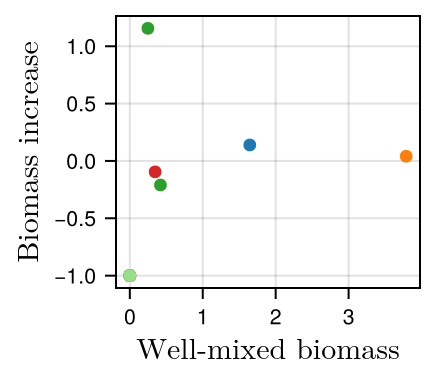

In [107]:
fig = Figure(;
    size=(double_col_width * 0.32, (double_col_width / golden_ratio) * 0.45),
    figure_padding=(8., 8., 8., 8.),
)

ax = Axis(fig[1,1];
    # aspect=DataAspect(),
    # aspect=AxisAspect(1.),
    xlabel="Well-mixed biomass",
    ylabel="Biomass increase",
    xlabelfont=xx.fonts.regular[],
    ylabelfont=xx.fonts.regular[],
    xlabelsize=10fontsize_ltex_pt,
    ylabelsize=10fontsize_ltex_pt,
    xticklabelsize=8fontsize_pt,
    yticklabelsize=8fontsize_pt,
)

# cs = [Makie.wong_colors()[mod(i, 7)+1] for i in 1:20]
cs = [ColorSchemes.tab20[mod(i, 7)+1] for i in 1:20]

scatter!(ax, ode_fs[1:N], (pde_means[1:N] .- ode_fs[1:N]) ./ ode_fs[1:N]; color=cs)
# scatter!(ax, ode_fs[1:N], (pde_means[1:N] .- ode_fs[1:N]); color=cs)
# scatter!(ax, ode_fs[1:N], (pde_means[1:N] ./ ode_fs[1:N]); color=cs)

# Makie.save("../../figures2/fig4/scatter_special.svg", fig)
Makie.save("../../figures2/fig4/scatter_differences.pdf", fig)

fig

# Total biomass change as a function of p
**This data is not good enough for the final version, need at least multiple repeats**

In [120]:
f = jldopen("../../cluster_env/runs/si_totbiom/run1system/data1_better.jld2")
df = f["df"];
fmd = f["metadata"];

N = fmd.N
M = fmd.M
sN = fmd.sN;

# spatial averages
df.means = [map(df.sol_us[i]) do u reshape(mean(u; dims=2), N+M) end for i in 1:nrow(df)];
# sum the 20 strains
df.totbioms = [map(mm) do mu sum(mu[1:N]) end for mm in df.means];

# just look at the final state
df.fs_totbioms = last.(df.totbioms);

ode_totbiom = sum(fmd.ode_fs[1:N]);

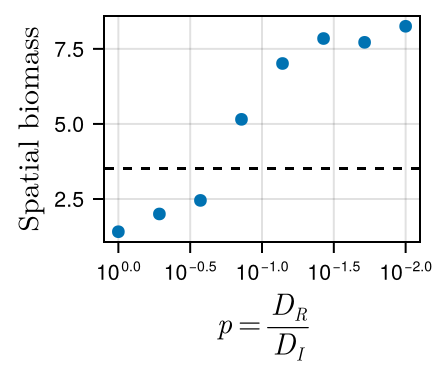

In [126]:
fig = Figure(;
    size=(double_col_width * 0.32, (double_col_width / golden_ratio) * 0.45),
    figure_padding=(8., 8., 8., 8.),
)

ax = Axis(fig[1,1];
    xscale=log10,
    xreversed=true,
    xlabel=L"p=\frac{D_R}{D_I}",
    ylabel="Spatial biomass",
    xlabelfont=xx.fonts.regular[],
    ylabelfont=xx.fonts.regular[],
    xlabelsize=10fontsize_ltex_pt,
    ylabelsize=10fontsize_ltex_pt,
    xticklabelsize=8fontsize_pt,
    yticklabelsize=8fontsize_pt,
)

scatter!(ax, df.ps, df.fs_totbioms)
hlines!(ax, [ode_totbiom]; color=:black, linestyle=:dash)

Makie.save("../../figures2/fig4/totbiom_vs_p.pdf", fig)

fig

# Space-time diagram (peak merging)

In [133]:
includet("../../scripts/si_spacetime_utils.jl")

In [134]:
f = jldopen("../../cluster_env/runs/si_totbiom/run1system/data1_better.jld2")
df = f["df"];
fmd = f["metadata"];

N = fmd.N
M = fmd.M
sN = fmd.sN;

## First one at p=1 shows merging

In [156]:
r = df[1,:];
@show r.ps;

totb_mat = hcat(map(r.sol_us) do x sum(x[1:N,:], dims=1)[:] end...);
sprel_totb_mat = totb_mat ./ maximum(totb_mat; dims=1);

cols_mat = hcat(map(r.sol_us) do u
    [get_rel_col_20(u[1:N,x]) for x in 1:size(u, 2)]
end...);

maxb = maximum(totb_mat)
scaled_cols_mat = map(zip(cols_mat, totb_mat)) do (c, b)
    alphacolor(c, b / maxb)
end;
sprel_scaled_cols_mat = map(zip(cols_mat, sprel_totb_mat)) do (c, b)
    alphacolor(c, b)
end;

r.ps = 1.0


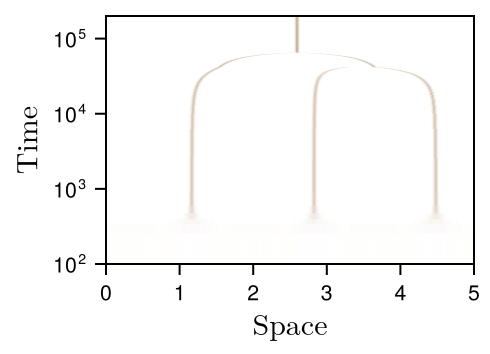

In [157]:
tedges = centres_to_edges_closed(r.sol_ts);
xedges = 0:fmd.dx:fmd.L

fig = Figure(;
    size=(double_col_width * 0.36, (double_col_width / golden_ratio) * 0.42),
    figure_padding=(8., 8., 8., 8.),
)

ax = Axis(fig[1,1];
    yscale=log10,
    xlabel="Space",
    ylabel="Time",
    xgridvisible=false,
    ygridvisible=false,
    xlabelfont=xx.fonts.regular[],
    ylabelfont=xx.fonts.regular[],
    xlabelsize=10fontsize_ltex_pt,
    ylabelsize=10fontsize_ltex_pt,
    xticklabelsize=8fontsize_pt,
    yticklabelsize=8fontsize_pt,
)

heatmap!(ax, xedges, tedges, scaled_cols_mat;
# heatmap!(ax, xedges, tedges, sprel_scaled_cols_mat;
    # colormap=ColorSchemes.Greys,
)

# ylims!(ax, 1e0, tedges[end])
ylims!(ax, 1e2, 2e5)

Makie.save("../../figures2/fig4/spacetime1.pdf", fig)

fig

## Maybe another at p < 1. showing spatial coexistence?

In [151]:
r = df[4,:];
@show r.ps;

totb_mat = hcat(map(r.sol_us) do x sum(x[1:N,:], dims=1)[:] end...);
sprel_totb_mat = totb_mat ./ maximum(totb_mat; dims=1);

cols_mat = hcat(map(r.sol_us) do u
    [get_rel_col_20(u[1:N,x]) for x in 1:size(u, 2)]
end...);

maxb = maximum(totb_mat)
scaled_cols_mat = map(zip(cols_mat, totb_mat)) do (c, b)
    alphacolor(c, b / maxb)
end;
sprel_scaled_cols_mat = map(zip(cols_mat, sprel_totb_mat)) do (c, b)
    alphacolor(c, b)
end;

r.ps = 0.13894954943731377


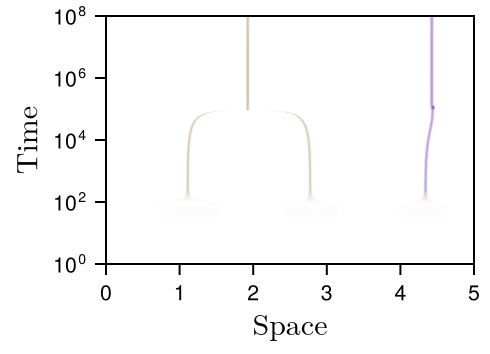

In [155]:
tedges = centres_to_edges_closed(r.sol_ts);
xedges = 0:fmd.dx:fmd.L

fig = Figure(;
    size=(double_col_width * 0.36, (double_col_width / golden_ratio) * 0.42),
    figure_padding=(8., 8., 8., 8.),
)

ax = Axis(fig[1,1];
    yscale=log10,
    xlabel="Space",
    ylabel="Time",
    xgridvisible=false,
    ygridvisible=false,
    xlabelfont=xx.fonts.regular[],
    ylabelfont=xx.fonts.regular[],
    xlabelsize=10fontsize_ltex_pt,
    ylabelsize=10fontsize_ltex_pt,
    xticklabelsize=8fontsize_pt,
    yticklabelsize=8fontsize_pt,
)

heatmap!(ax, xedges, tedges, scaled_cols_mat;
# heatmap!(ax, xedges, tedges, sprel_scaled_cols_mat;
    # colormap=ColorSchemes.Greys,
)

ylims!(ax, 1e0, tedges[end])
# ylims!(ax, 1e2, 2e5)

Makie.save("../../figures2/fig4/spacetime2.pdf", fig)

fig

# Example PDE final state V2
WIP

In [9]:
f = jldopen("../../cluster_env/runs/si_totbiom/speeding_up_qndf/data2.jld2")
df = f["df"];
fmd = f["metadata"];

N = fmd.N
M = fmd.M
sN = fmd.sN;

0.0025:0.005:4.9975000000000005

r.sol_ts[ti] = 215.48050593975364


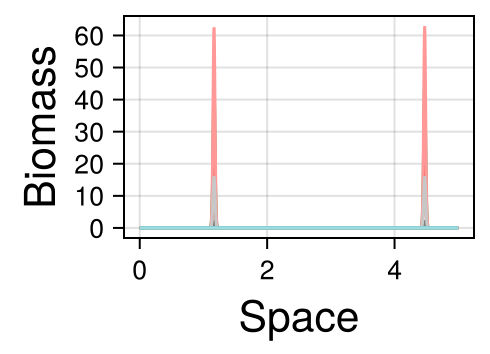

In [77]:
r = df[1,:];

ti = length(r.sol_ts)
ti = 27
@show r.sol_ts[ti]

f = plot_spatial_fs(r.sol_us[ti], N, fmd.sN, fmd.dx;
    scolor=i->ColorSchemes.tab20[i],
    rcolor=i->Cycled(i),
)

fig = Figure(;
    size=(double_col_width * 0.36, (double_col_width / golden_ratio) * 0.42),
    figure_padding=(8., 8., 8., 8.),
)

ax = Axis(fig[1,1];
    xlabel="Space",
    ylabel="Biomass",
    # xlabelfont=xx.fonts.regular[],
    # ylabelfont=xx.fonts.regular[],
    xlabelsize=16fontsize_pt,
    ylabelsize=16fontsize_pt,
    xticklabelsize=10fontsize_pt,
    yticklabelsize=10fontsize_pt,
)

ti = length(r.sol_ts)
ti = 200
# ti = 29
xs = get_spatial_gridpoints_dx(sN, fmd.L / sN)
for i in 1:N
    xx = r.sol_us[ti][i,:]
    lines!(ax, xs, xx; color=ColorSchemes.tab20[i])
end

# xlims!(ax, 0., 2.)

# Makie.save("../../figures2/other_bits/spatial_fs_early_time.pdf", fig)
Makie.save("../../figures2/other_bits/spatial_fs_late_time.pdf", fig)

fig

# Community composition in PDEs as p changes
I'm not actually 100% sure what this was meant to be but do have a look at the cluster_env/runs/si_totbiom/run1system/Changing... notebook I suspect it'll either answer any questions or be simple to modify to asnwer any